# Exploratory Data Analysis & Data Processing



### Index
1. Initial data exploration
2. Data processing
3. Variable definition

In [ ]:
# imports
# -------

from pathlib import Path
import pyarrow

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEmbeddings
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import plotly.graph_objects as go

import sys
sys.path.append(str(Path("../../src").resolve())) # or uv sync - but this will always work instead
from pricing_amazon_products.io import save_df
from pricing_amazon_products.plotting import plot_feature_distribution
from pricing_amazon_products.embeddings import build_embedding_df
from pricing_amazon_products.preprocessing import (
    extract_catalog_subsections, 
    extract_catalog_field,
    UNIT_MAP
)
from pricing_amazon_products.config import (
    RAW_DIR,
    INTERIM_DIR,
    PROCESSED_DIR,
    EMBEDDINGS_DIR,
    SPLITS_DIR,
    EMBEDDING_SOURCE_COL, 
    EMBEDDING_MODELS
)
from pricing_amazon_products.config import TARGET

pd.set_option("display.max_colwidth", None)

import warnings
warnings.filterwarnings('ignore')

load_dotenv(override=True)

c:\Users\gonza\Documents\pricing-amazon-products\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

## Configuration

----

Runtime switches:

`OVERWRITE_MODE` should be changed with care, because it overwrites intermediate artifacts generated in previous runs, substantially rising computational cost.

In [ ]:
# -------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------

OVERWRITE_MODE = False

## 1 | Initial Data Exploration

----

- Dataset size
- Quick overview of the content of the dataset
- Quick overview of the target variable distribution

In [3]:
df_raw = pd.read_csv(RAW_DIR/ 'train.csv')

In [4]:
# we check data size

df_raw.shape

(75000, 4)

In [5]:
# We check columns and their types

df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        75000 non-null  int64  
 1   catalog_content  75000 non-null  str    
 2   image_link       75000 non-null  str    
 3   price            75000 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 71.2 MB


In [6]:
df_raw.loc[0]

sample_id                                                                                                   33127
catalog_content    Item Name: La Victoria Green Taco Sauce Mild, 12 Ounce (Pack of 6)\nValue: 72.0\nUnit: Fl Oz\n
image_link                                                    https://m.media-amazon.com/images/I/51mo8htwTHL.jpg
price                                                                                                        4.89
Name: 0, dtype: object

In [7]:
df_raw[df_raw['price'] <= 0]

,sample_id,catalog_content,image_link,price


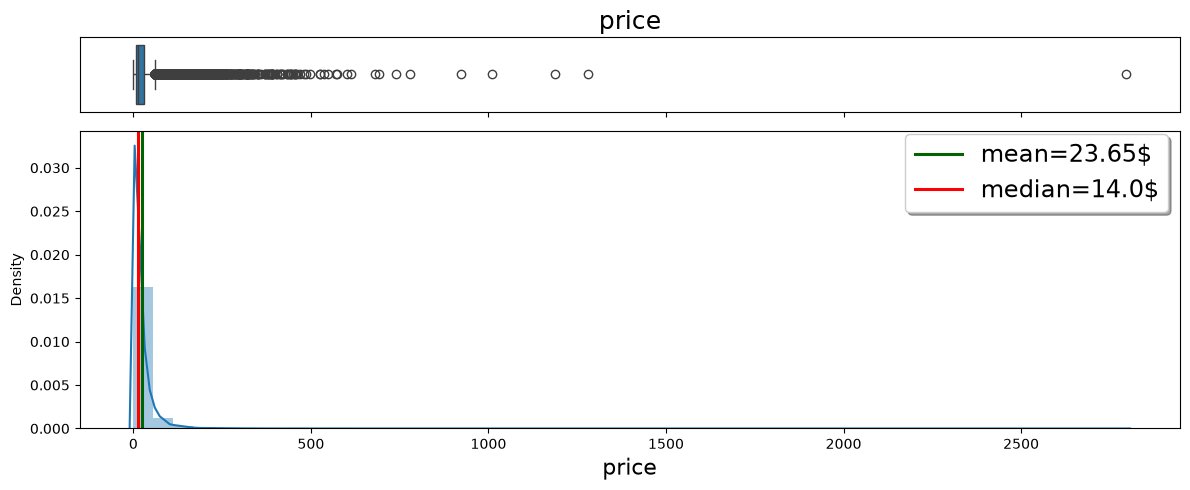

In [8]:
# Target variable 

plot_feature_distribution(df_raw, 'price', 'price', '$')

In [9]:
df_raw[df_raw['price'] == df_raw['price'].max()]

,sample_id,catalog_content,image_link,price
58617,229126,"Item Name: 4Patriots 1-Year Survival Food Kit: Emergency Food Supply Designed to Last 25 Years, 2,752 Servings\nBullet Point 1: 2,752 EMERGENCY FOOD SERVINGS: 24 delicious survival food recipes like Grammy's Sweet Oatmeal and America's Finest Mac & Cheese. This freeze-dried food has about 7.6 servings a day. Your Emergency Food Supply has an average of 543,360 calories (~1,509 a day - you may want or need more). Perfect prepper supplies with a 25 year shelf life.\nBullet Point 2: “DISASTER-RESISTANT” EMERGENCY FOOD: Triple-layer Mylar premium packaging acts as a barrier to protect your survival food against things that harm your food: air, light & moisture. We use a high-tech, high-capacity oxygen absorber to suck OUT any excess air. So your emergency food supply can keep an amazing 25 year shelf life. (longer than MREs).\nBullet Point 3: PACKED IN USA, NO ADDED MSG: Your survival food is packed at a family-owned facility in Utah using the best ingredients from the US & around the world. The folks that make your emergency food are experts in their field; nutritionists, chefs, engineers, & quality control inspectors. Our facility is SQF certified & registered with the USDA and FDA.\nBullet Point 4: EASY TO PREPARE SURVIVAL MEALS: Your prepper food is easy to make & tastes better than MREs. Just add boiling water, simmer and serve. It takes about 15 minutes from start to finish. In an instant, you'll have tasty emergency food to get you through a crisis. With 24 unique survival meals, you get delicious variety in your emergency food supply.\nBullet Point 5: LONG-TERM PEACE OF MIND: With a 1-Year supply of survival food on hand, you’ll be better prepared to handle an emergency situation. From dangerous storms and blackouts to supply chain disruptions, this long-lasting food store could be a lifesaver in a crisis.\nBullet Point 6: DESIGNED WITH A 25 YEAR SHELF LIFE: Storage conditions impact 25 year shelf life of your prepper supplies. For best results, protect food from heat, air & moisture. Avoid temps above 75 F°. Keep emergency food sealed until ready to eat. Shelf life varies based on storage conditions.You may want or need more calories. See below for more info.\nBullet Point 7: +YOU MAY WANT OR NEED MORE CALORIES PER DAY especially if you’re pregnant, a child, elderly, or have health conditions. Your survival food kit is designed to provide energy & nutrients for 1 person in an emergency, not to be a complete caloric replacement during normal times. We recommend an emergency food supply for everyone in your family.\nBullet Point 8: *Ships in Mulitple Packages\nProduct Description: The 1-Year Survival Food Kit gives you 2,752 servings of delicious emergency food to add to your prepper supplies. This freeze-dried food is designed with a 25 year shelf life (longer than MREs). You get ""stick-to-your-ribs"" emergency food for breakfast, lunch, and dinner. Not to mention, mouthwatering desserts to stockpile in your survival food supply. Plus, real milk and energy drinks to wash it all down. Each 1-Year Survival Food Supply gives you: 2,752 servings – (7.6/day average) 543,360 total calories – (~1,509 per day)+ 24 delicious recipes you can prepare in minutes It's the perfect long-term emergency food supply for Americans. And a great stash for your prepper supplies. The secret is our incredible 25 year shelf life. Our freeze-dried food uses an advanced sealing process to give your prepper food an amazing 25 year shelf life. It’s why we recommend this survival food over MREs. And now, you get a 1 year supply of tasty survival food shipped straight to your door. +You may want or need more calories per day,+ especially if you’re pregnant, a child, elderly, or have other health conditions.\nValue: 1.0\nUnit: Count\n",https://m.media-amazon.com/images/I/81WiVwz7KkL.jpg,2796.0


**Observations**:

- Dataset size: **75k Amazon products**; each instance contains 4 variables
- The target variable is `price`, which is highly skewed to the right
    - A transformation of the target variable seems reasonable to avoid the impact of outliers aligning the target variable distribution to the loss
- Regarding the three remaining columns:
    - `sample_id` is an identifier and will not help the model, so it can be discarded.
    - `catalog_content` contains the product description and is heavily populated. We will need to extract numerical features from it.
    - `image_link` points to a product image on the web. Image-based modeling would require downloading and processing the images, which is out of scope for the current iteration.
- Initial data quality check:
    - `info()` reports no null values in the main columns.
    - We still need to verify whether empty strings or placeholder values such as `N/A` are present in the categorical fields.

## 2 | Data processing

----

- Deduplication
- Target transformation
- Feature engineering and missing values analysis
- Feature relevance checks
- Embedding generation from product description

**Departing point**:

|       df_raw         | dtype |
|------------------|---|
| ``catalog_content``  | str |
| ``price``            | float | 

### **Deduplication**


In [10]:
# Let's see if some products are duplicated, or at least its catalog description

checks = {
    "full row (catalog, image, price)": ["catalog_content", "image_link", "price"],
    "catalog + price": ["catalog_content", "price"],
    "image + price": ["image_link", "price"],
    "catalog + image": ["catalog_content", "image_link"],
    "catalog": ["catalog_content"],
    "image": ["image_link"],
}

rows = []
for name, subset in checks.items():
    n_unique = df_raw.drop_duplicates(subset=subset).shape[0]
    n_extra = len(df_raw) - n_unique
    
    rows.append({
        "check": name,
        "unique_instances": n_unique,
        "duplicated_instances": n_extra,
    })

summary_df = pd.DataFrame(rows)
summary_df

,check,unique_instances,duplicated_instances
0,"full row (catalog, image, price)",74987,13
1,catalog + price,74973,27
2,image + price,74656,344
3,catalog + image,74954,46
4,catalog,74900,100
5,image,72288,2712


In [11]:
# Let's see products with the same description (catalog_content) but different price

(
    df_raw
    .groupby("catalog_content")
    .filter(lambda x: x["price"].nunique() > 1)
    .sort_values(by='catalog_content')
    .head(2)
)

,sample_id,catalog_content,image_link,price
11795,185463,"Item Name: AmazonFresh Hazelnut Flavored Coffee, Ground, Medium Roast, 12 Ounce\nBullet Point 1: Fragrant medium-light roast with toasted hazelnut flavor\nBullet Point 2: One 12-ounce bag of ground coffee\nBullet Point 3: 100% Arabica coffee grown in Central and South America\nBullet Point 4: Roasted and packed in the U.S.A.\nBullet Point 5: Shown as a serving suggestion\nBullet Point 6: An Amazon brand\nValue: 12.0\nUnit: Ounce\n",https://m.media-amazon.com/images/I/81w29mbZOtL.jpg,7.29
63885,188458,"Item Name: AmazonFresh Hazelnut Flavored Coffee, Ground, Medium Roast, 12 Ounce\nBullet Point 1: Fragrant medium-light roast with toasted hazelnut flavor\nBullet Point 2: One 12-ounce bag of ground coffee\nBullet Point 3: 100% Arabica coffee grown in Central and South America\nBullet Point 4: Roasted and packed in the U.S.A.\nBullet Point 5: Shown as a serving suggestion\nBullet Point 6: An Amazon brand\nValue: 12.0\nUnit: Ounce\n",https://m.media-amazon.com/images/I/81w29mbZOtL.jpg,7.64


In [12]:
# summary of price spread between products with more than one price

summary = (
    df_raw.groupby("catalog_content", as_index=False)
    .agg(
          n_different_prices=("price", "nunique"),
          min_price=("price", "min"),
          max_price=("price", "max"),
          avg_price=("price", "mean"),
          median_price=("price", "median"),
    )
    .query('n_different_prices > 1')
    .assign(rel_price_spread=lambda x: (x["max_price"] - x["min_price"]) / x["avg_price"].replace(0, pd.NA))
)

summary.describe()

,n_different_prices,min_price,max_price,avg_price,median_price,rel_price_spread
count,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000
mean,2.089552,14.597090,25.904030,20.216162,20.129515,0.451585
std,0.336260,19.759894,42.805477,29.451400,29.479219,0.454417
min,2.000000,1.125000,2.790000,2.460000,2.460000,0.003918
25%,2.000000,4.540000,6.740000,6.103750,5.841250,0.111024
50%,2.000000,7.990000,14.055000,10.515000,10.120000,0.343780
75%,2.000000,15.320000,26.880000,21.113750,21.113750,0.561419
max,4.000000,100.920000,320.450000,196.060000,196.060000,1.766112


**Duplicates Analysis Observations**:

- Most rows (>99%) appear to be unique products (product descriptions - prices)
- 67 products (<1%) share the same `catalog_content` but differ in `price`
- These cases need a dedicated treatment before modeling
- The few product with more than one price can have very large price dispersion (45% price dispersion). This suggest:
    - that the same product is sold by different sellers, or simply on different quantities, or even at different times
    - or this can mean that prices are small and slight price differences are substantial differences in relative terms
- **median aggregation** is the selected method for multi-prices products.



In [13]:
# Aggregation

df_agg = df_raw.groupby('catalog_content', as_index=False).agg(agg_price=('price', 'median'))

df_agg.head(2)

,catalog_content,agg_price
0,"Item Name 1: Item# 610-401\nItem Name 2: Icing Color, 1 oz. - Food Coloring\nValue: 1.0\nUnit: Count\n",6.06
1,"Item Name 1: Item# 610-655\nItem Name 2: Icing Color, 1 oz. - Food Coloring\nValue: 1.0\nUnit: Count\n",2.12


**Current state of the data processing:**

Current working dataframe: `df_agg`

| Variable | dtype | Status | Derived from variable |
|---|---|---|---|
| `catalog_content` | str | raw | `catalog_content` |
| `agg_price` | float | aggregated during deduplication | `price` |

### **Target Transformation**

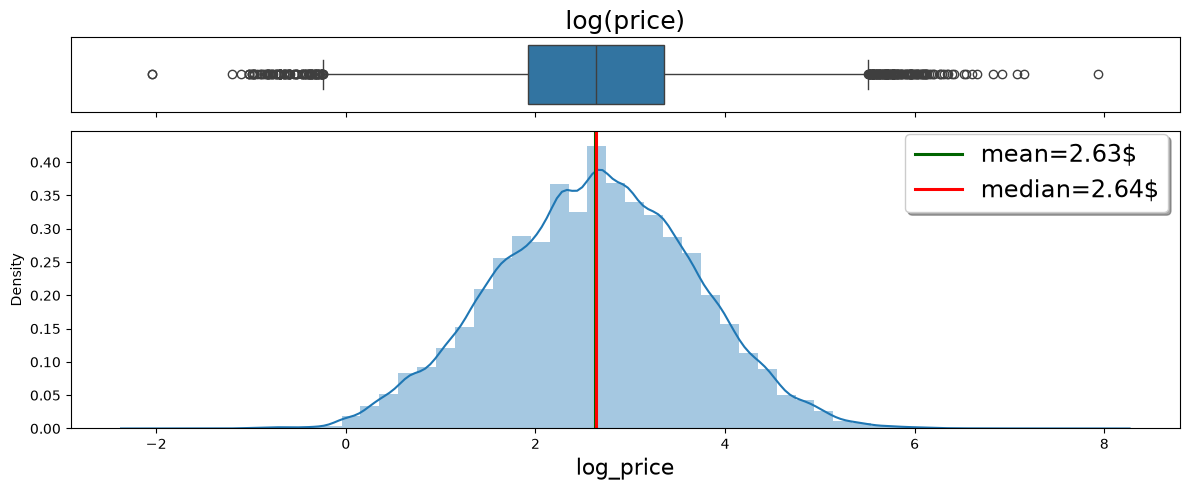

In [14]:
# Target transformation: check whether transforming `price` helps reduce skewness, stabilize variance and improve model fit.
# Log transformation as the distribution of the target variable is highly skewed

"""Taking the natural logarithm of the variable can help reduce the skewness"""

df_agg['log_price'] = np.log(df_agg['agg_price'])
plot_feature_distribution(df_agg, 'log_price', 'log(price)', '$')

In [15]:
df_agg['log_price'].describe()

count    74900.000000
mean         2.631044
std          1.040326
min         -2.040221
25%          1.916923
50%          2.639057
75%          3.355153
max          7.935945
Name: log_price, dtype: float64

**Target transformation observations**:

We created a new column `log_price` with the logarithmic transformed price. After the transformation the target is substantitally more symmetrical and approximately Gaussian. The range is much more balance around the center and the median (`2.639`) is very close to the mean (`2.631`).

In the models where the loss functions expect additive rather than multiplicative errors (MSE, RMSE) then modelling `log(price)` may be preferable.



**Current state of the data processing**:

Current working dataframe: `df_agg`

| Variable | dtype |Status | Derived from |
|---|---|---|---|
| `catalog_content` | str | raw | `catalog_content` |
| `agg_price` | float |aggregated during deduplication | `price` |
| `log_price` | float |log-transformed target | `agg_price` |

### **Feature engineering and Missing Values Analysis**

We retrieve numerical features from `catalog_content` variable

In [16]:
df_raw.head(3)

,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, 12 Ounce (Pack of 6)\nValue: 72.0\nUnit: Fl Oz\n",https://m.media-amazon.com/images/I/51mo8htwTHL.jpg,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butter Cookies, 8 Ounce (Pack of 4)\nBullet Point 1: Original Butter Cookies: Classic butter cookies made with real butter\nBullet Point 2: Variety Pack: Includes 4 boxes with 32 cookies total\nBullet Point 3: Occasion Perfect: Delicious cookies for birthdays, weddings, anniversaries\nBullet Point 4: Shareable Treats: Fun to give and enjoy with friends and family\nBullet Point 5: Salerno Brand: Trusted brand of delicious butter cookies since 1925\nValue: 32.0\nUnit: Ounce\n",https://m.media-amazon.com/images/I/71YtriIHAAL.jpg,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy Chicken with Rice, 1.9 Ounce (Pack of 6)\nBullet Point 1: Loaded with hearty long grain wild rice and vegetables\nBullet Point 2: Full of hearty goodness\nBullet Point 3: Single serve bowls\nBullet Point 4: Easy to prepare mix\nBullet Point 5: 0 grams trans fat\nValue: 11.4\nUnit: Ounce\n",https://m.media-amazon.com/images/I/51+PFEe-w-L.jpg,1.97


The `catalog_content`column contains a semi-structured product description. Repeated fields are:

- Item Name: ...
- Bullet: ...
- Value: ...
- Unit: ...

In [17]:
# Let's see what are the most repeated fields and their relative presence across catalogs

df_subsections = df_agg["catalog_content"].apply(extract_catalog_subsections)
all_labels = sorted(set(label for labels in df_subsections for label in labels))

rows = []
n_products = len(df_agg)

for label in all_labels:
    n_with_label = df_subsections.apply(lambda labels: label in labels).sum()
    pct_with_label = np.round(100 * n_with_label / n_products, 2)
    rows.append({
        "subsection": label,
        "n_products": n_with_label,
        "pct_products": pct_with_label
    })

subsection_summary = pd.DataFrame(rows).sort_values("pct_products", ascending=False).reset_index(drop=True)
subsection_summary

,subsection,n_products,pct_products
0,Unit,74900,100.00
1,Value,74900,100.00
2,Item Name,74893,99.99
3,Bullet Point 2,54427,72.67
4,Bullet Point 1,54427,72.67
5,Bullet Point 3,52535,70.14
6,Bullet Point 4,48086,64.20
7,Bullet Point 5,41407,55.28
8,Product Description,32515,43.41
9,Bullet Point,6243,8.34


In [18]:
pct_threshold = 0.99


for e in subsection_summary[subsection_summary["pct_products"] > pct_threshold*100]["subsection"].unique():
    col_name = e.lower().replace(" ", "_")
    df_agg[col_name] = df_agg["catalog_content"].apply(lambda x, e=e: extract_catalog_field(x, e))
    df_agg[col_name] = df_agg[col_name].str.lower()

In [19]:
df_agg.iloc[29:33]

,catalog_content,agg_price,log_price,unit,value,item_name
29,Item Name: (16 Pk.) of Favorita Wafers (Galletas Favorita from Puerto Rico)\nValue: 171.52\nUnit: Ounce\n,14.85,2.698000,ounce,171.52,(16 pk.) of favorita wafers (galletas favorita from puerto rico)
30,Item Name: (2 Pack) - Green & Blacks - Organic Hot Chocolate | 300g | 2 PACK BUNDLE\nValue: 600.0\nUnit: Gram\n,20.65,3.027715,gram,600.0,(2 pack) - green & blacks - organic hot chocolate | 300g | 2 pack bundle
31,"Item Name: (2 Pack) - Pataks - Chilli Pickle | 283g | 2 PACK BUNDLE\nBullet Point 1: Patak's\nBullet Point 2: Chilli Pickle, Mixed with authentic spices\nBullet Point 3: Can be eaten with any other food you fancy\nBullet Point 4: Great quality product from Patak\nBullet Point 5: 283g x 2\nValue: 19.97\nUnit: Ounce\n",22.70,3.122365,ounce,19.97,(2 pack) - pataks - chilli pickle | 283g | 2 pack bundle
32,Item Name: (2 Pack) Las Palmas Green Enchilada Sauce HOT/Picante 28 Ounces\nValue: 56.0\nUnit: Ounce\n,2.88,1.057790,ounce,56.0,(2 pack) las palmas green enchilada sauce hot/picante 28 ounces


**Handling Nulls**

In [20]:
# It generated only one null in `item_name`, and another in `unit`

df_agg.info()

<class 'pandas.DataFrame'>
RangeIndex: 74900 entries, 0 to 74899
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   catalog_content  74900 non-null  str    
 1   agg_price        74900 non-null  float64
 2   log_price        74900 non-null  float64
 3   unit             74899 non-null  str    
 4   value            74900 non-null  str    
 5   item_name        74899 non-null  str    
dtypes: float64(2), str(4)
memory usage: 75.4 MB


Nulls are present in:
- unit (1 null)
- item_name (1 null)

Additionally, we see that `value` variable is string while we expect a float. Type conversion is required. Maybe it generates nulls.

In [21]:
# this catalog is malformed, item name exists but is empty -> let's discard it

df_agg[df_agg['item_name'].isnull()]

,catalog_content,agg_price,log_price,unit,value,item_name
7,"Item Name: \nBullet Point 1: 🔬Tested for heavy metals & metalloid levels. Learn more.\nBullet Point 2: Deliciously pureed apple, blueberry & ginger for baby\nBullet Point 3: 35mg of beta-glucan to help support a strong and healthy immune system\nBullet Point 4: No artificial preservatives, colors or flavors and no added sweeteners\nBullet Point 5: Non-GMO (made with ingredients that are not genetically modified)\nBullet Point 6: Single 4-oz recyclable glass jar\nProduct Description: \nValue: 60.0\nUnit: Count\n",1.29,0.254642,count,60.0,NaN


In [22]:
# unit has a null value, but it has a default value that can replace it

df_agg[df_agg['unit'].isnull()]

,catalog_content,agg_price,log_price,unit,value,item_name
14255,"Item Name: Coffee Pods, French Roast, Single Cup, 14/Box\nBullet Point: { ""language_tag"": ""en_US"", ""value"": ""UPC: 766047308003"", ""marketplace_id"": ""ATVPDKIKX0DER"" }\nProduct Description: <p>Individually wrapped coffee pods appeal to a variety of tastes. Can be used with most home single-cup coffeemakers.</p>\nValue: 1.0\nUnit: \n",21.22,3.054944,NaN,1.0,"coffee pods, french roast, single cup, 14/box"


In [23]:
df_model = (
    df_agg
    .assign(unit=lambda x: x["unit"].fillna("count"))  # default value when null
    .dropna(subset=["item_name"])  # malformed record; can't fill reliably
    .assign(value=lambda x: x['value'].astype(float))
)

In [24]:
# we observe if nulls are present in `value` after type transformation

df_model[df_model['value'].isnull()].head(1)

,catalog_content,agg_price,log_price,unit,value,item_name
9,"Item Name: ""Boars Night Out"" Championship BBQ Rub 10.5 Ounce\nValue: nan\nUnit: None\n",12.405,2.5181,none,NaN,"""boars night out"" championship bbq rub 10.5 ounce"


In [25]:
# value is null when unit is `none` (not null but none) 

df_model[df_model['unit'] == 'none']['value'].unique()

array([nan])

In [26]:
# we make sure that value is null only when unit is null as well

df_model[df_model['value'].isnull()]['unit'].unique()

<ArrowStringArray>
['none']
Length: 1, dtype: str

In [27]:
df_model[df_model['value'].isnull()].shape[0] / df_model.shape[0]

0.012510180376240004

In [28]:
# in instances when value is null an app

df_model["value"] = df_model["value"].fillna(1)

**`value` variable distribution**

In [29]:
df_model['value'].describe()

count    74899.000000
mean        53.651045
std        459.255209
min          0.000000
25%          6.000000
50%         16.000000
75%         48.000000
max      63882.000000
Name: value, dtype: float64

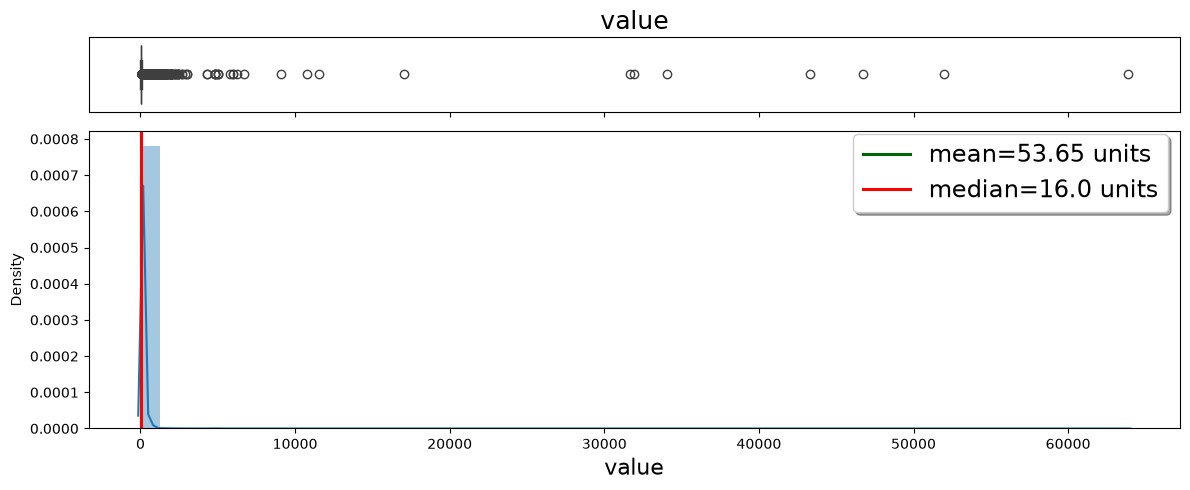

In [30]:
plot_feature_distribution(df_model, 'value', 'value', ' units')

In [31]:
df_model[df_model['value'] > 60000]

,catalog_content,agg_price,log_price,unit,value,item_name
2090,"Item Name: Alpine Spring Water, 16.9 oz Bottle, 35/Case, 108 Cases/2 Pallets\nValue: 63882.0\nUnit: Fl Oz\n",21.55,3.070376,fl oz,63882.0,"alpine spring water, 16.9 oz bottle, 35/case, 108 cases/2 pallets"


In [32]:
# log of value

df_model['log_value'] = np.log1p(df_model['value'])

In [33]:
df_model['log_value'].describe()

count    74899.000000
mean         2.904485
std          1.410300
min          0.000000
25%          1.945910
50%          2.833213
75%          3.891820
max         11.064809
Name: log_value, dtype: float64

**`unit` one-hot encoding**

Transforming `unit` categorical variable into a numerical one
**One-hot encoding**, frequency encoding and label-encoder are the first options at hand. Let's dig into this variable to see which one fits the task at hand.

Frequency of Units
--------------------------------------------------


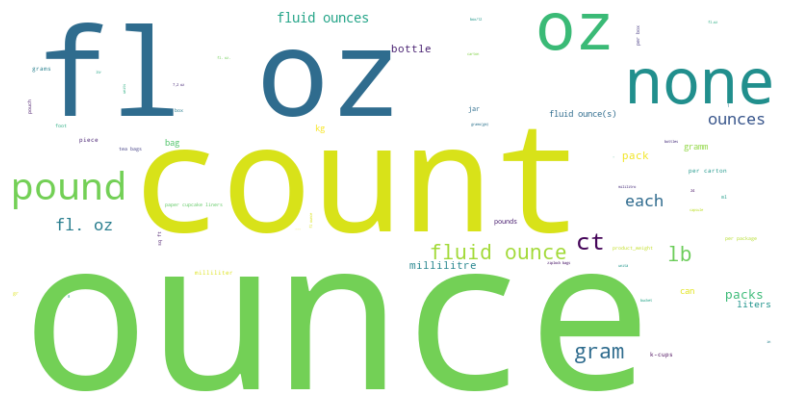

In [34]:
# Let's see if 'unit' is noisy or a good signal

word_counts = df_model["unit"].value_counts()
wordcloud = WordCloud(width=800, height=400, background_color='white')
wordcloud.generate_from_frequencies(word_counts)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
print('Frequency of Units')
print('--------------------------------------------------')
plt.show()

In [35]:
df_model["unit_clean"] = (
    df_model["unit"]
    .str.strip()
    .str.lower()
    .replace(UNIT_MAP)
)

In [36]:
df_model["unit_clean"].value_counts(normalize=True).head(20)

unit_clean
ounce          0.587364
count          0.243782
fluid_ounce    0.150843
none           0.012510
pound          0.003151
gram           0.000521
packs          0.000160
millilitre     0.000120
pack           0.000120
bottle         0.000120
liters         0.000093
can            0.000080
kg             0.000080
gramm          0.000080
bag            0.000080
pounds         0.000053
jar            0.000053
piece          0.000040
k-cups         0.000040
per carton     0.000040
Name: proportion, dtype: float64

In [37]:
# keep top categories and group the rest

pct_threshold = 0.01
top_units = (
    df_model["unit_clean"]
    .value_counts(normalize=True)
    .loc[lambda s: s > pct_threshold]
    .index
)
df_model["unit_grouped"] = df_model["unit_clean"].where(
    df_model["unit_clean"].isin(top_units),
    "other"
)

In [38]:
df_model["unit_grouped"].value_counts(normalize=True)

unit_grouped
ounce          0.587364
count          0.243782
fluid_ounce    0.150843
none           0.012510
other          0.005501
Name: proportion, dtype: float64

In [39]:
# encoding unit and dropping all unit columns

df_model = pd.get_dummies(df_model, columns=["unit_grouped"], drop_first=True, dtype=int)
df_model = df_model.drop(columns=['unit_clean'])

**Categorical Features Transformation observations**:

- We observed the content of `catalog_content` and realized that the field was not plain natural language, but a semi-structured field with many repeated subsections. We found that three fields are present in more than 99% of the products: `Item Name` (or `Item Name 1`), `Value`, and `Unit`. Hence, we extracted these into three new features.
- We transformed the `unit` column by normalizing its values, grouping equivalent variants into a smaller set of categories, and then applying one-hot encoding. 


### **Feature Relevance Check**

- Constant or near-constant variables: remove them if they do not provide predictive value.
- Correlation analysis: study multicollinearity and remove redundant features only if they add noise or instability.

In [40]:
# We check for constant variables

df_constant = df_model.loc[:, df_model.apply(pd.Series.nunique) != 1]
print('Number of constant variables: ', len(df_model) - len(df_constant))

Number of constant variables:  0


In [41]:
# To avoid multi-collinearity, we detect the variables that have a high correlation with each other (>90%)

(
    df_model
    .drop(columns=["agg_price", "log_price"], errors="ignore")
    .corr(numeric_only=True)
    .style
    .map(lambda x: "background-color: brown;" if abs(x) > 0.90 else None)
)

,value,log_value,unit_grouped_fluid_ounce,unit_grouped_none,unit_grouped_other,unit_grouped_ounce
value,1.000000,0.209166,0.049801,-0.012904,0.030541,-0.024236
log_value,0.209166,1.000000,0.220369,-0.176487,-0.026315,0.056281
unit_grouped_fluid_ounce,0.049801,0.220369,1.000000,-0.047439,-0.031346,-0.502851
unit_grouped_none,-0.012904,-0.176487,-0.047439,1.000000,-0.008371,-0.134288
unit_grouped_other,0.030541,-0.026315,-0.031346,-0.008371,1.000000,-0.088732
unit_grouped_ounce,-0.024236,0.056281,-0.502851,-0.134288,-0.088732,1.000000


**Observations**

Among the numerical variables, we did not find strong multicollinearity (otherwise they would be highlighted in red). If it were present, we could reduce overfitting by removing redundant columns, especially those less related to the target variable. Since we do not observe high multicollinearity, we do not need to prioritize correlation-based feature pruning at this stage.

In [42]:
df_features = df_model.copy().reset_index(drop=True)
df_features["row_id"] = df_features.index

features_path =  INTERIM_DIR / "df_features.parquet"
save_df(df_features, features_path, overwrite=OVERWRITE_MODE)

Skipping df_features.parquet (already exists and overwrite mode set to False)


**Final state of the data processing**:

Current working dataframe: `df_features`

| Variable | dtype | Status | Derived from |
|---|---|---|---|
| `row_id` | `int` | unique row identifier | dataframe index |
| `catalog_content` | `str` | raw | `catalog_content` |
| `agg_price` | `float` | aggregated (median) during deduplication | `price` |
| `log_price` | `float` | log-transformed target | `agg_price` |
| `item_name` | `str` | extracted from `catalog_content` | `catalog_content` |
| `value` | `float` | extracted from `catalog_content` | `catalog_content` |
| `log_value` | `float` | log of `value` | `value` |
| `unit` | `str` | extracted from `catalog_content` | `catalog_content` |
| `unit_grouped_fluid_ounce` | `int` | one-hot encoded categorical feature | `unit` |
| `unit_grouped_none` | `int` | one-hot encoded categorical feature | `unit` |
| `unit_grouped_other` | `int` | one-hot encoded categorical feature | `unit` |
| `unit_grouped_ounce` | `int` | one-hot encoded categorical feature | `unit` |

### **Embedding generation from product description**


Either `item_name` or `catalog_content` are text files. We can use **sentence-transformer embeddings** to transform these columns into huge dimensional vectors that represent the semantic point of that text. We can apply this technique to either of both text columns. While `catalog_content` might be more complete, it can be the case that it is quite noisy and that the simpler `item_name` can better reflect the product. Thus, we will convert the text into embedding and incorportate that into the model training set as numerical features. 

Interesting open-source models:

| Model name | max tokens | Weight | Total dimensions | ~ Time to run locally (on 75K instances) | Approx. MTEB position (as of June 2026) |
| --- | --- | --- | --- | --- | --- |
| `sentence-transformers/all-MiniLM-L6-v2` | 256 | 22.7M parameters | 384 | 12 min for item_name | 133rd |
| `avsolatorio/GIST-small-Embedding-v0` | 512 | 33M parameters | 384 | 25 min for item_name (>1h for catalog_content) | 50th |
| `google/embeddinggemma-300m` | 2048 | 300M parameters | 768 | ~3-4h | 32nd |

[Further open source models](https://huggingface.co/spaces/mteb/leaderboard)

In [43]:
# These are the models the nb is considering

embedding_models_df = pd.DataFrame.from_dict(EMBEDDING_MODELS, orient="index")
embedding_models_df

,max_tokens,weight_in_million_params,dimensions,mteb_position
sentence-transformers/all-MiniLM-L6-v2,256,23,384,133
avsolatorio/GIST-small-Embedding-v0,512,33,384,50


In [44]:
# IN this case both embeddings models have the same number of tokens per columns
# As running this is computationally expensive, let's print the lighter model generated token count

LIGHTER_EMBEDDING_MODEL = embedding_models_df["weight_in_million_params"].idxmin()
tokenizer = AutoTokenizer.from_pretrained(LIGHTER_EMBEDDING_MODEL)

summary = df_features.copy()
item_names = df_features["item_name"].fillna("").tolist()
catalog_contents = df_features["catalog_content"].fillna("").tolist()
summary["item_name_token_count"] = [len(tokenizer(t, add_special_tokens=True)["input_ids"]) for t in item_names]
summary["catalog_content_token_count"] = [len(tokenizer(t, add_special_tokens=True)["input_ids"]) for t in catalog_contents]
summary[["item_name_token_count", "catalog_content_token_count"]].describe()

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (696 > 512). Running this sequence through the model will result in indexing errors


,item_name_token_count,catalog_content_token_count
count,74899.000000,74899.000000
mean,25.371340,214.498244
std,12.438431,193.538624
min,3.000000,12.000000
25%,16.000000,67.000000
50%,22.000000,154.000000
75%,32.000000,298.000000
max,113.000000,1719.000000


In [45]:
token_limit_summary = []

for model_name in embedding_models_df.index:
    max_tokens = embedding_models_df.loc[model_name, "max_tokens"]
    pct_over_limit = (summary["catalog_content_token_count"] > max_tokens).mean() * 100

    token_limit_summary.append({
        "model_name": model_name,
        "max_tokens": max_tokens,
        "pct_over_limit": f"{int(pct_over_limit)}%",
    })

token_limit_summary_df = pd.DataFrame(token_limit_summary)
token_limit_summary_df

,model_name,max_tokens,pct_over_limit
0,sentence-transformers/all-MiniLM-L6-v2,256,31%
1,avsolatorio/GIST-small-Embedding-v0,512,10%


Approximately 10.18% of the product descriptions (`catalog_content`) exceed the 512-token limit of the embedding model (`GIST-small-Embedding-v0`), so some information will be truncated during embedding.

For as the variable `item_name`, 100% of instances meet the token limit. 

In [46]:
for model_name in embedding_models_df.index:
    build_embedding_df(df_features, EMBEDDING_SOURCE_COL, model_name, EMBEDDINGS_DIR)

Skipping item_name__sentence-transformers_all-MiniLM-L6-v2.parquet (already exists and overwrite is False)
Skipping item_name__avsolatorio_GIST-small-Embedding-v0.parquet (already exists and overwrite is False)


### Data processing scheme

```text
+------------------+
|      df_raw      |
|------------------|
| catalog_content  |
| price            |
+------------------+
         |
         | deduplication
         v
+------------------+
|      df_agg      |
|------------------|
| catalog_content  |
| agg_price        |
+------------------+
         |
         | target transformation
         v
+------------------+
|      df_agg      |
|------------------|
| catalog_content  |
| agg_price        |
| log_price        |
+------------------+
         |
         | feature extraction I 
         v
+------------------+
|     df_agg     |
|------------------|
| catalog_content  |
| agg_price        |
| log_price        |
| item_name        |
| value            |
| unit             |
+------------------+
         |
         | Null handling and feature extraction II 
         v
+------------------+
|    df_features   |
+------------------+
| row_id           |
| catalog_content  |
| agg_price        |
| log_price        |
| item_name        |
| value            |
| log value        |
| unit             |
| unit_grouped_*   |
+------------------+
         &
+------------------+
|   df_embedding   |
+------------------+
| row_id           |
| item_name_emb_*  |
+------------------+

In [47]:
# Merging features + desired embedding

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df_features = pd.read_parquet(INTERIM_DIR)

processed_dfs = {}
for emb_path in EMBEDDINGS_DIR .glob("*.parquet"):
    processed_path = PROCESSED_DIR / f"df_processed__{emb_path.stem}.parquet"

    df_embedding = pd.read_parquet(emb_path)

    if len(df_embedding) != len(df_features):
        raise ValueError(f"{emb_path.name}: embeddings do not match df_features length")

    if "row_id" not in df_embedding.columns:
        raise ValueError(f"{emb_path.name}: missing 'row_id' column")

    if not df_embedding["row_id"].is_unique:
        raise ValueError(f"{emb_path.name}: duplicated row_id values")

    if "agg_price" not in df_features.columns:
        raise ValueError("df_features is missing target column 'agg_price'")

    embedding_cols = [c for c in df_embedding.columns if c != "row_id"]

    if processed_path.exists() and not OVERWRITE_MODE:
        df_processed = pd.read_parquet(processed_path)
    else:
        df_processed = df_features.merge(df_embedding, on="row_id", how="left")
        save_df(df_processed, processed_path, overwrite=OVERWRITE_MODE)

    processed_dfs[emb_path.stem] = df_processed[["log_price"] + embedding_cols]

## 3 | Variable definition

----

We keep `df_features` as the cleaned and canonical dataframe. It contains the processed variables after deduplication, target transformation, and feature extraction.

From this base dataframe, we will build separate datasets for different experiments:
- `y`: log price target
- `X_base`: scaled `value` + `unit` dummies
- `X_with_text_catalog_content`: `catalog_content`
- `X_with_embeddings_col__model`: `X_base` + embedding features extracted from a given text column (`item_name` or `catalog_content`)

`row_id` will be kept in the saved split artifacts to preserve traceability and enable merges, but it will be dropped before fitting the models.

In [ ]:
# Target
df_features = pd.read_parquet(INTERIM_DIR)

# Split
train_idx, test_idx = train_test_split(df_features.index, test_size=0.2, random_state=42)

df_train = df_features.loc[train_idx].copy()
df_test = df_features.loc[test_idx].copy()

if TARGET not in df_train.columns:
    raise ValueError(
        f"{TARGET} not found in df_train. Please, indicate a valid TARGET in the corresponding config file"
    )

y_train = df_train[["row_id", TARGET]]
y_test = df_test[["row_id", TARGET]]

In [ ]:
# X_base

base_cols = ["row_id", "log_value"] + [c for c in df_train.columns if c.startswith('unit_grouped_')]

X_train_base = df_train[base_cols].copy()
X_test_base = df_test[base_cols].copy()

In [50]:
# X_features with catalog_context text (it can be interesting for an LLM to predict directly from the description)

X_train_catalog_content = df_train[['row_id', 'catalog_content']]
X_test_catalog_content = df_test[['row_id', 'catalog_content']]

In [51]:
save_df(y_train, SPLITS_DIR / "y_train.parquet", OVERWRITE_MODE)
save_df(y_test, SPLITS_DIR / "y_test.parquet", OVERWRITE_MODE)

save_df(X_train_base, SPLITS_DIR / "X_train_base.parquet", OVERWRITE_MODE)
save_df(X_test_base, SPLITS_DIR / "X_test_base.parquet", OVERWRITE_MODE)

save_df(X_train_catalog_content, SPLITS_DIR / "X_train_catalog_content.parquet", OVERWRITE_MODE)
save_df(X_test_catalog_content, SPLITS_DIR / "X_test_catalog_content.parquet", OVERWRITE_MODE)


Skipping y_train.parquet (already exists and overwrite mode set to False)
Skipping y_test.parquet (already exists and overwrite mode set to False)
Skipping X_train_base.parquet (already exists and overwrite mode set to False)
Skipping X_test_base.parquet (already exists and overwrite mode set to False)
Skipping X_train_catalog_content.parquet (already exists and overwrite mode set to False)
Skipping X_test_catalog_content.parquet (already exists and overwrite mode set to False)


In [52]:
# X_features with embeddings

for emb_path in EMBEDDINGS_DIR.glob("*.parquet"):
    df_embedding = pd.read_parquet(emb_path)

    if "row_id" not in df_embedding.columns:
        raise ValueError(f"{emb_path.name} does not contain row_id")

    if not df_embedding["row_id"].is_unique:
        raise ValueError(f"{emb_path.name} has duplicated row_id values")

    emb_name = emb_path.stem

    X_train_with_embeddings = X_train_base.merge(df_embedding, on="row_id", how="left")
    X_test_with_embeddings = X_test_base.merge(df_embedding, on="row_id", how="left")

    save_df(X_train_with_embeddings, SPLITS_DIR / f"X_train_with_embeddings__{emb_name}.parquet", OVERWRITE_MODE)
    save_df(X_test_with_embeddings, SPLITS_DIR / f"X_test_with_embeddings__{emb_name}.parquet", OVERWRITE_MODE)

Skipping X_train_with_embeddings__item_name__avsolatorio_GIST-small-Embedding-v0.parquet (already exists and overwrite mode set to False)
Skipping X_test_with_embeddings__item_name__avsolatorio_GIST-small-Embedding-v0.parquet (already exists and overwrite mode set to False)
Skipping X_train_with_embeddings__item_name__sentence-transformers_all-MiniLM-L6-v2.parquet (already exists and overwrite mode set to False)
Skipping X_test_with_embeddings__item_name__sentence-transformers_all-MiniLM-L6-v2.parquet (already exists and overwrite mode set to False)


## Next Steps

----

To extend this work, possible improvements are:

- Prevent data leakage in the preprocessing pipeline, especially in:
  - the creation of the one-hot `unit`-based columns, since the top categories were selected using the full dataset frequency
  - the deduplication step, since repeated `catalog_content` entries with multiple prices were aggregated using the median price across the full dataset

- Predict the product category and encode it as a one-hot feature, for example:
  `['Appliances', 'Automotive', 'Cell_Phones_and_Accessories', 'Electronics', 'Musical_Instruments', 'Office_Products', 'Tools_and_Home_Improvement', 'Toys_and_Games']`.
  This could be done with a text classification approach.

- Improve the embedding-based features by benchmarking different text embedding models, especially larger or higher-quality ones, and comparing their impact on model performance.